____
# Spatial filtering of SWOT


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, coloc_swot, rotate_ggd, add_grid_metrics

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

___________
# CHOOSE

_______
# Data

In [21]:
dfs = browse_swot_250().reset_index()
dss = xr.open_dataset(dfs.file.iloc[10])
dss = add_grid_metrics(dss)

In [37]:
sla = dss.duacs_ssha_karin_2_calibrated.where(dss.duacs_editing_flag==0).interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines')
mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)

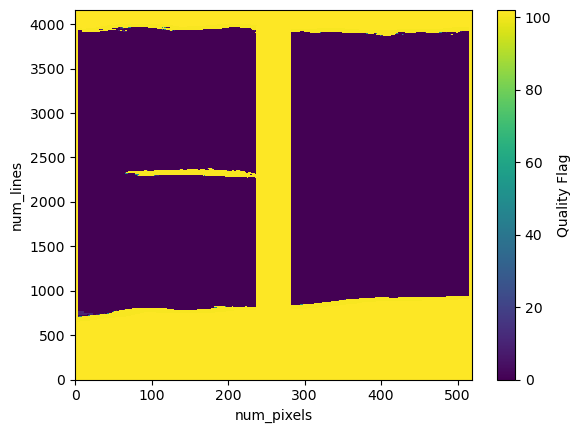

In [70]:
dss.duacs_editing_flag.plot()

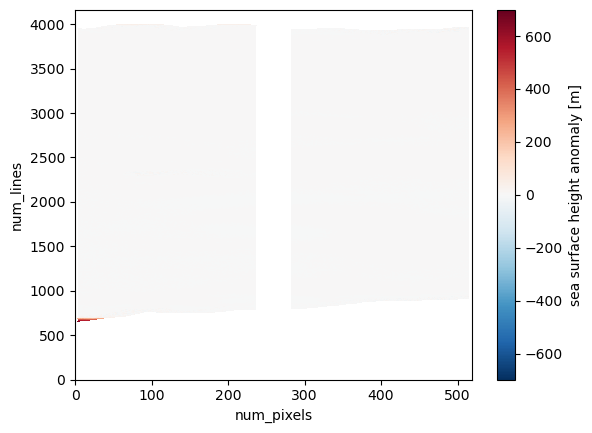

In [72]:
dss.duacs_ssha_karin_2_calibrated.plot()

# Snapshots

In [100]:
dx = float(sla.dx.mean())
cutoff = 5e3


from scipy.ndimage import convolve1d
from scipy.ndimage import gaussian_filter

# Gaussian a la mano
lambda_cutoff = cutoff/dx
sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
Mg = 2 * round(4*sigma_cutoff)+1
import scipy.signal.windows as wdw
gaussian = wdw.gaussian(Mg,  std = sigma_cutoff)


sla = dss.duacs_ssha_karin_2_calibrated.where(dss.duacs_editing_flag==0)
mask = dss.duacs_editing_flag.where(dss.duacs_editing_flag!=0,1).where(dss.duacs_editing_flag==0,0)

fg = xr.DataArray(convolve1d(convolve1d(sla.fillna(0), gaussian, axis=0), gaussian, axis=1), dims=sla.dims)#unnromalized
fm = xr.DataArray(convolve1d(convolve1d(mask, gaussian, axis=0), gaussian, axis=1), dims=mask.dims)#unnormalized
fg = fg/fm

fgp = xr.DataArray(gaussian_filter(sla.interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines'), sigma=cutoff/dx, order=[0,0]), dims=sla.dims)
fmask = xr.DataArray(gaussian_filter(mask, sigma=cutoff/dx, order=[0,0]), dims=mask.dims)

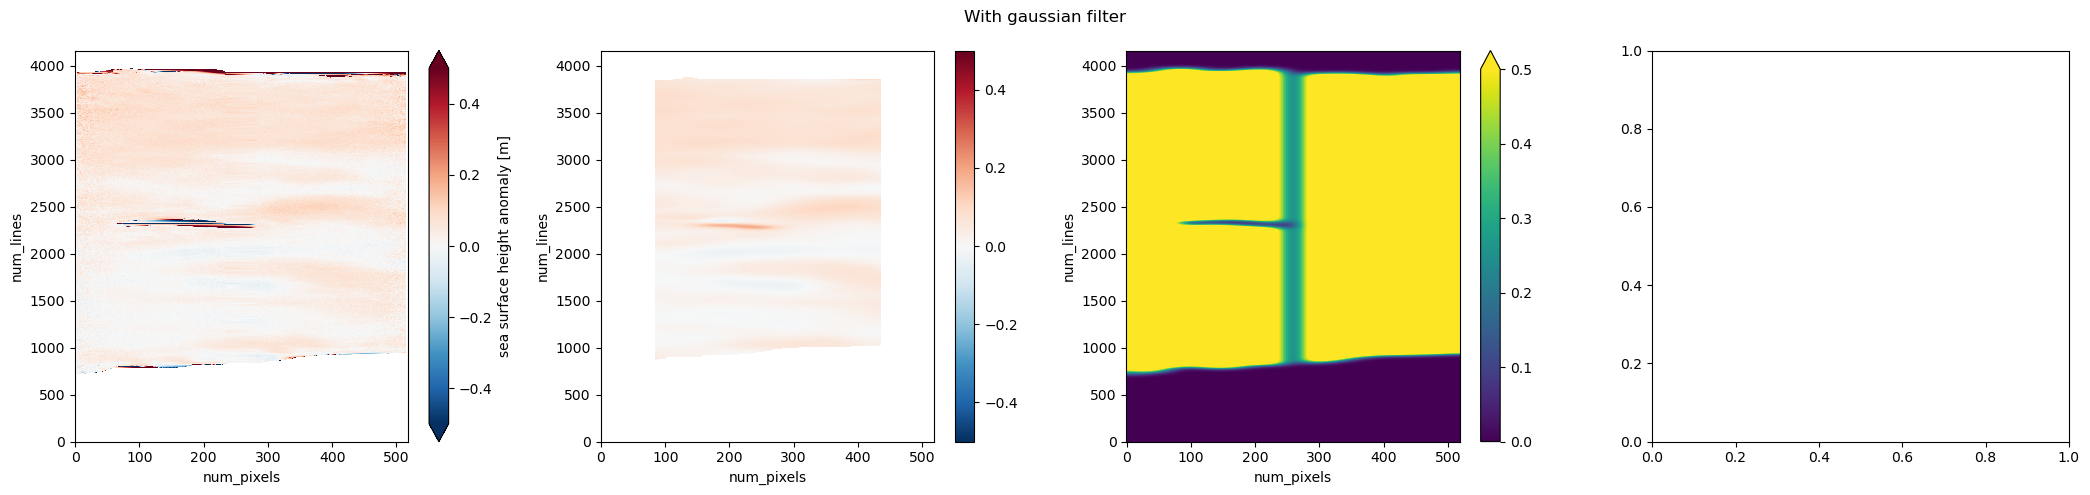

In [91]:
fig, axs = plt.subplots(1,4, figsize=(21, 5))
sla.interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines').plot(vmax=0.5, ax=axs[0])
fgp.plot(vmax=0.5, ax=axs[1])
fmask.plot(vmax=0.5, ax=axs[2])
fig.suptitle('With gaussian filter')

fig.tight_layout()

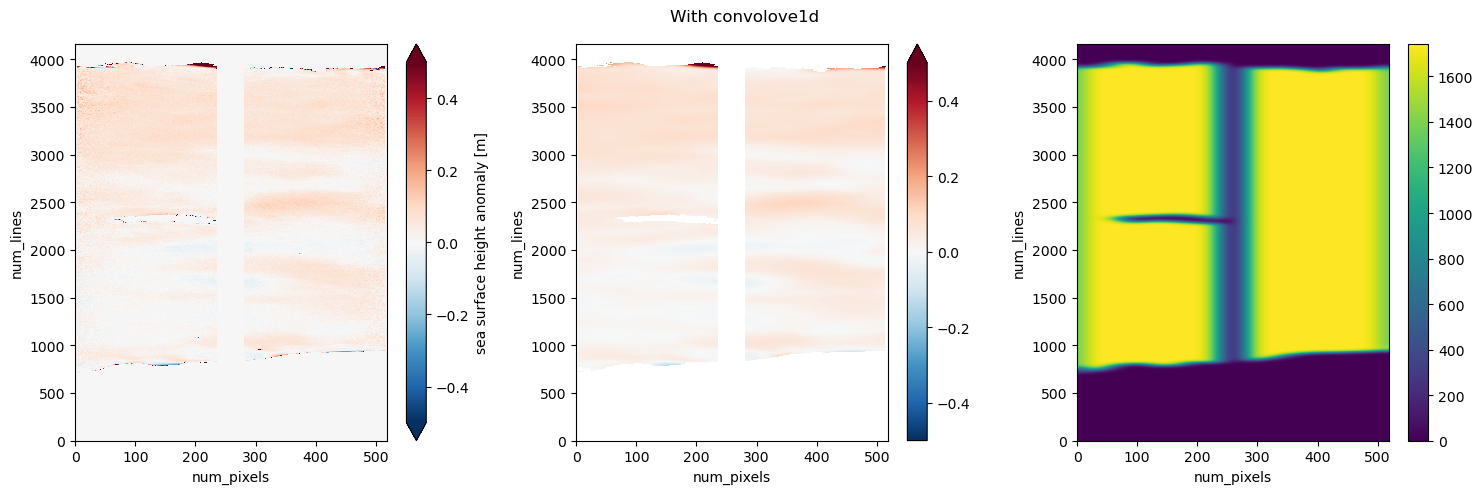

In [92]:

fig, axs = plt.subplots(1,3, figsize=(15, 5))
sla.fillna(0).plot(vmax=0.5, ax=axs[0])
fg.where(mask==1).plot(vmax=0.5, ax=axs[1])
fm.plot(ax=axs[2])
fig.suptitle('With convolove1d')
fig.tight_layout()

# Gaussian gradient

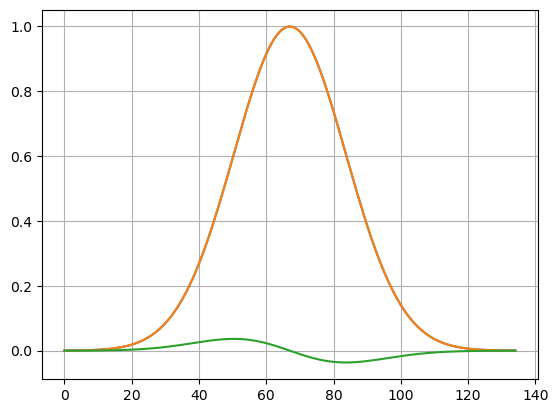

In [114]:
### Derivative

def gaussian_(sigma_cutoff, Mg):
    n = np.arange(Mg)
    mu = Mg//2
    return np.exp(-(n-mu)**2/2/sigma_cutoff**2)

    
def gaussian_diff(sigma_cutoff, Mg):
    n = np.arange(Mg)
    mu = Mg//2
    return -(n-mu)/sigma_cutoff**2 * np.exp(-(n-mu)**2/2/sigma_cutoff**2)


plt.plot(np.arange(Mg), gaussian_(sigma_cutoff, Mg))
plt.plot(np.arange(Mg), gaussian)
plt.plot(np.arange(Mg), gaussian_diff(sigma_cutoff, Mg))
plt.grid()

In [116]:
diff = gaussian_diff(sigma_cutoff, Mg)

In [178]:
def convolve_gauss_gradient(sla, mask):
    f1 = xr.DataArray(convolve1d(sla.fillna(0), gaussian, axis=1), dims=sla.dims)
    m1 = xr.DataArray(convolve1d(mask.fillna(0), gaussian, axis=1), dims=sla.dims)
    fm1 = f1/m1
    f1d0 = xr.DataArray(convolve1d(fm1, diff, axis=0), dims=sla.dims)
    m1d0 = xr.DataArray(convolve1d(m1, diff, axis=0), dims=sla.dims)


    f0 = xr.DataArray(convolve1d(sla.fillna(0), gaussian, axis=0), dims=sla.dims)
    m0 = xr.DataArray(convolve1d(mask.fillna(0), gaussian, axis=0), dims=sla.dims)
    fm0 = f0/m0
    f0d1 = xr.DataArray(convolve1d(fm1, diff, axis=1), dims=sla.dims)
    m0d1 = xr.DataArray(convolve1d(m1, diff, axis=1), dims=sla.dims)

    return f1,m1,f1d0, m1d0, f0,m0,f0d1, m0d1


In [179]:
f1,m1,f1d0, m1d0, f0,m0,f0d1, m0d1 = convolve_gauss_gradient(sla, mask)

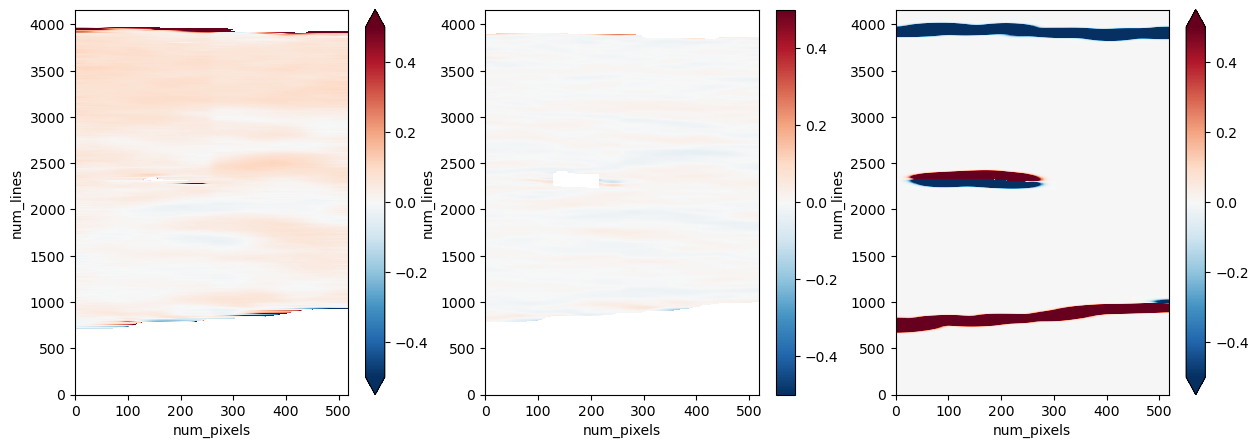

In [183]:
fig, axs = plt.subplots(1,3, figsize=(15, 5))

(f1/m1).plot(vmax=0.5, ax=axs[0])
f1d0.plot(vmax=0.5, ax=axs[1])
m1d0.plot(vmax=0.5, ax=axs[2])

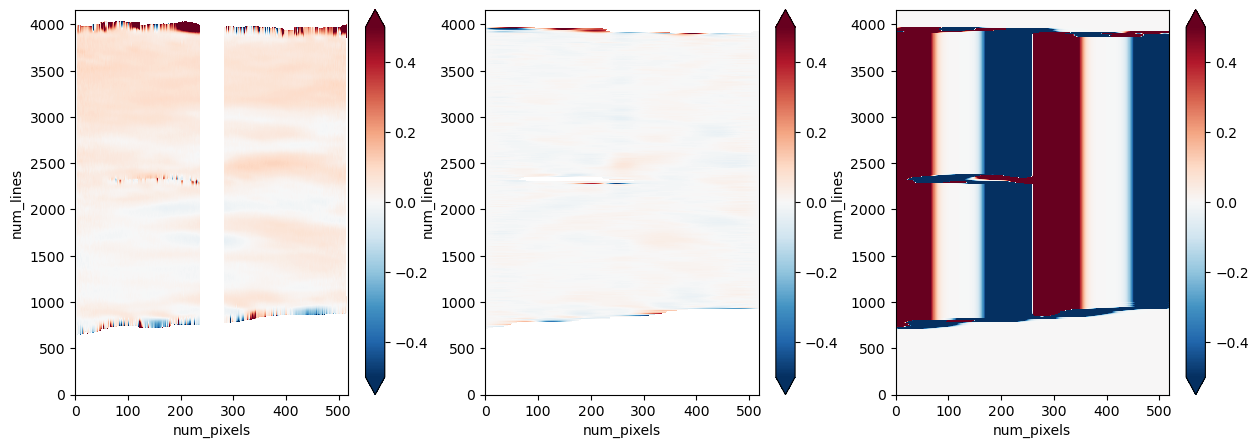

In [184]:
fig, axs = plt.subplots(1,3, figsize=(15, 5))

(f0/m0).plot(vmax=0.5, ax=axs[0])
f0d1.plot(vmax=0.5, ax=axs[1])
m0d1.plot(vmax=0.5, ax=axs[2])

In [191]:
g=9.81

ggd_variables = ['cvl_mean_dynamic_topography_cnes_cls_22',
                 'cvl_mean_sea_surface_cnes_22_hybrid',
                 'cvl_ocean_tide_fes_2022',
                 'cvl_ssha_reference',
                 'duacs_ssha_karin_2_calibrated',
                 'duacs_ssha_karin_2_filtered',]


def gradient_gauss(dss, cutoff, ggd_variables=None, **kwargs):
    
    if ggd_variables : dss_ggd = dss[ggd_variables]
    else : dss_ggd = dss
    
    dx = float(dss_ggd.dx.mean())
    dy = float(dss_ggd.dy.mean())

    dss_ggdx = xr.Dataset()
    dss_ggdy = xr.Dataset()
    
    for v in dss_ggd : 
        print(v)
        da = dss_ggd[v].interpolate_na(dim='num_pixels').interpolate_na(dim='num_lines')# prevent nan to spread
        
        # cross-track
        i = da.get_axis_num("num_pixels")
        order = [0,0]
        order[i] = 1
        dss_ggdx['ggdx_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dx, order=order, **kwargs), dims=da.dims)/dx).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
        #da_dx = da_dx.where(da)
        
        # along-track
        i = da.get_axis_num("num_lines")
        order = [0,0]
        order[i] = 1
        dss_ggdy['ggdy_'+v] = g*(xr.DataArray(gaussian_filter(da, sigma=cutoff/dy, order=order, **kwargs), dims=da.dims)/dy).where(~dss['duacs_ssha_karin_2_filtered'].isnull())
        
    return xr.merge([dss_ggdx, dss_ggdy])

dgg = gradient_gauss(dss, cutoff, ggd_variables)

cvl_mean_dynamic_topography_cnes_cls_22
cvl_mean_sea_surface_cnes_22_hybrid
cvl_ocean_tide_fes_2022
cvl_ssha_reference
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered


duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated
duacs_ssha_karin_2_filtered
duacs_ssha_karin_2_calibrated


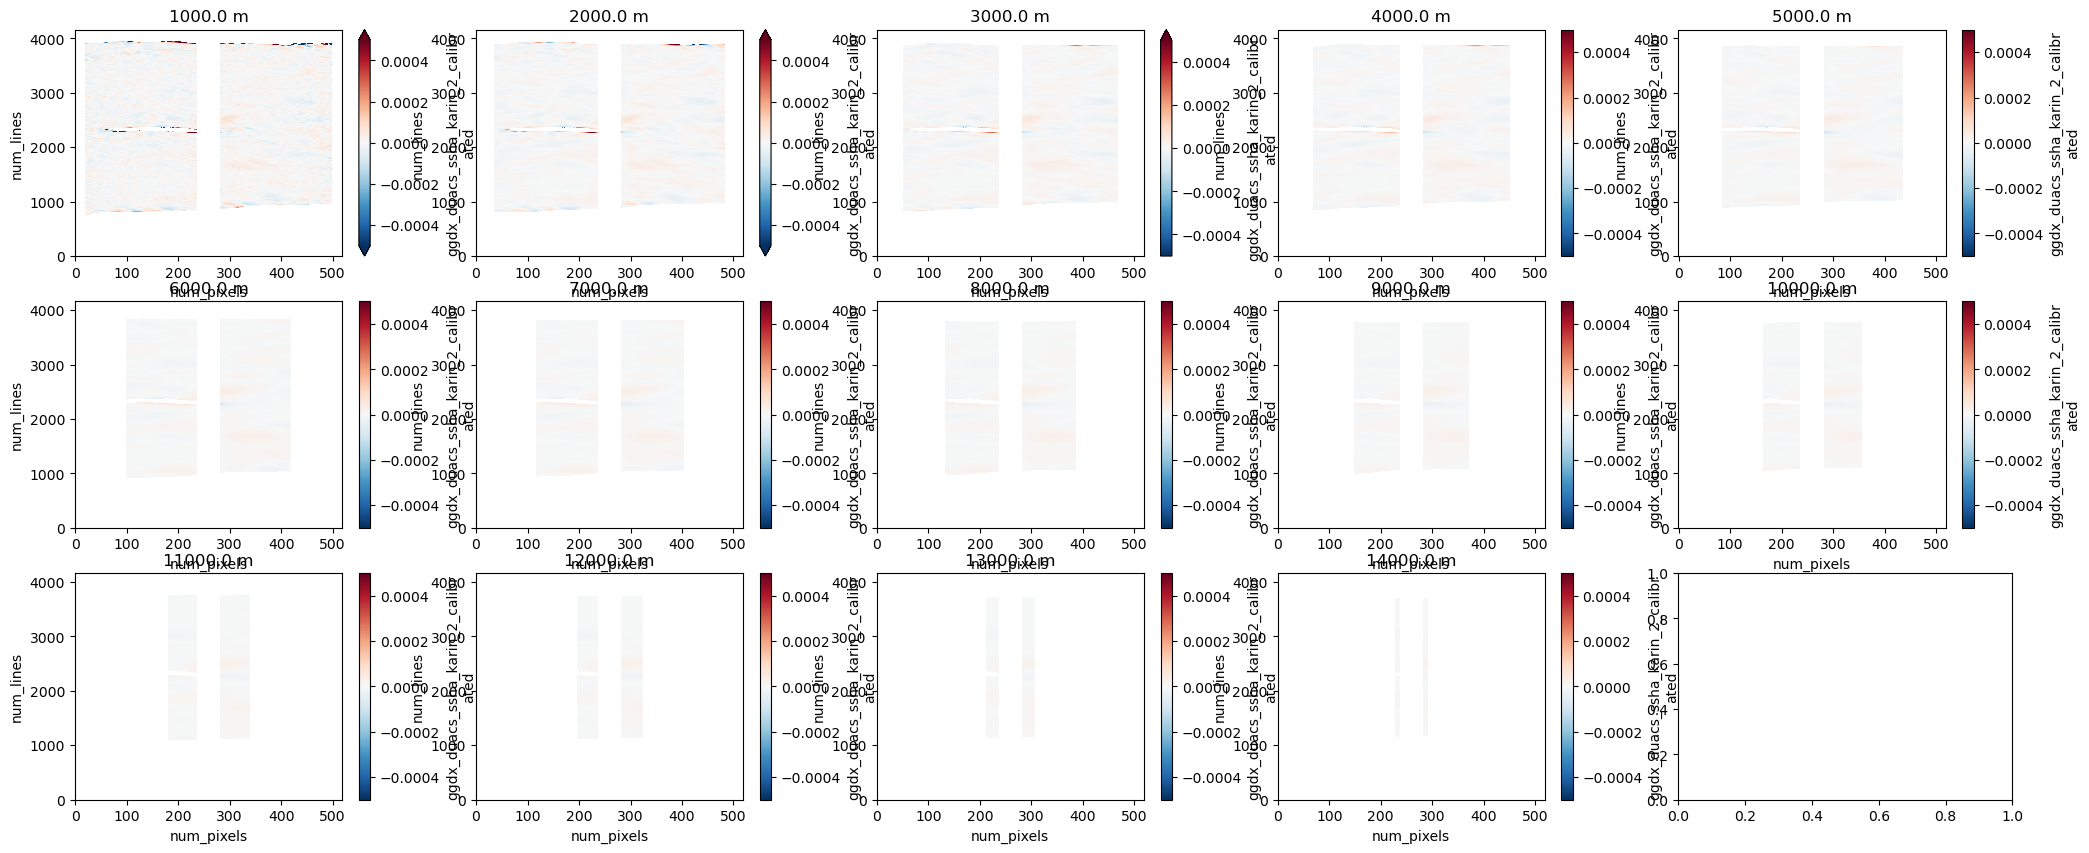

In [205]:
Cutoff = np.arange(1e3, 15e3, 1e3)

fig, axs = plt.subplots(3,5, figsize=(25, 10))
axs = axs.flatten()
for i in range(len(Cutoff)):
    dgg = gradient_gauss(dss.where(dss.duacs_editing_flag==0), Cutoff[i], ggd_variables = ['duacs_ssha_karin_2_filtered', 'duacs_ssha_karin_2_calibrated'])
    dgg.ggdx_duacs_ssha_karin_2_calibrated.plot(ax=axs[i], vmax  =5e-4)
    axs[i].set_title(f'{Cutoff[i]} m')